# 06 — Advanced Styling
**Goal:** Make charts that look production-ready — ready for a dashboard, a PDF report, or a presentation.

Topics:
- Custom color palettes
- Typography: fonts, weight, size hierarchy
- `rcParams` — one block to rule all charts
- Patch styling (bars, fills)
- Saving at the right resolution for different outputs
- Building a reusable style function

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

Path('data').mkdir(exist_ok=True)

df = pd.read_csv('data/raw/funnel_data.csv', parse_dates=['date'])
daily = df.groupby('date').agg(
    sessions=('visita_landing', 'sum'),
    activations=('activacion_tarjeta', 'sum'),
).reset_index()
by_channel = df.groupby('channel')['activacion_tarjeta'].sum().sort_values(ascending=False)
print('Ready')

Ready


## 1 — Color palettes
Define your brand palette once. Never hardcode colors inside chart functions.

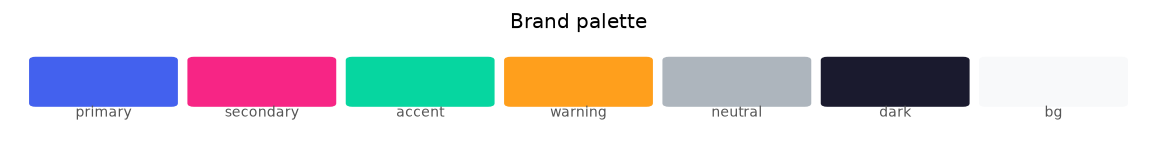

In [2]:
# Fintech brand palette
COLORS = {
    'primary':   '#4361ee',
    'secondary': '#f72585',
    'accent':    '#06d6a0',
    'warning':   '#ff9f1c',
    'neutral':   '#adb5bd',
    'dark':      '#1a1a2e',
    'bg':        '#f8f9fa',
}

# Sequential palette for multi-series charts (5 channels)
CHANNEL_COLORS = ['#4361ee', '#f72585', '#06d6a0', '#ff9f1c', '#7209b7']

# Visualize the palette
fig, ax = plt.subplots(figsize=(9, 1.2), dpi=130)
for i, (name, color) in enumerate(COLORS.items()):
    ax.add_patch(mpatches.FancyBboxPatch(
        (i * 1.4, 0), 1.2, 0.8,
        boxstyle='round,pad=0.05', color=color
    ))
    ax.text(i * 1.4 + 0.6, -0.25, name, ha='center', fontsize=8, color='#555')

ax.set_xlim(-0.2, len(COLORS) * 1.4)
ax.set_ylim(-0.5, 1.2)
ax.axis('off')
ax.set_title('Brand palette', fontsize=11)
plt.tight_layout()
plt.show()

## 2 — rcParams: one block to style all charts
`plt.rcParams.update({...})` sets defaults for every chart in the session.

In [3]:
# Run this once at the top of any notebook/script
plt.rcParams.update({
    # Figure
    'figure.dpi':           130,
    'figure.facecolor':     'white',
    'figure.autolayout':    True,

    # Font
    'font.family':          'sans-serif',
    'font.size':            11,
    'axes.titlesize':       13,
    'axes.titleweight':     'bold',
    'axes.labelsize':       11,
    'xtick.labelsize':      10,
    'ytick.labelsize':      10,

    # Spines & grid
    'axes.spines.top':      False,
    'axes.spines.right':    False,
    'axes.grid':            True,
    'grid.color':           '#e8e8e8',
    'grid.linewidth':       0.8,
    'axes.axisbelow':       True,

    # Lines
    'lines.linewidth':      2.0,

    # Legend
    'legend.frameon':       False,
    'legend.fontsize':      10,
})

print('rcParams applied — all subsequent charts use these defaults')

rcParams applied — all subsequent charts use these defaults


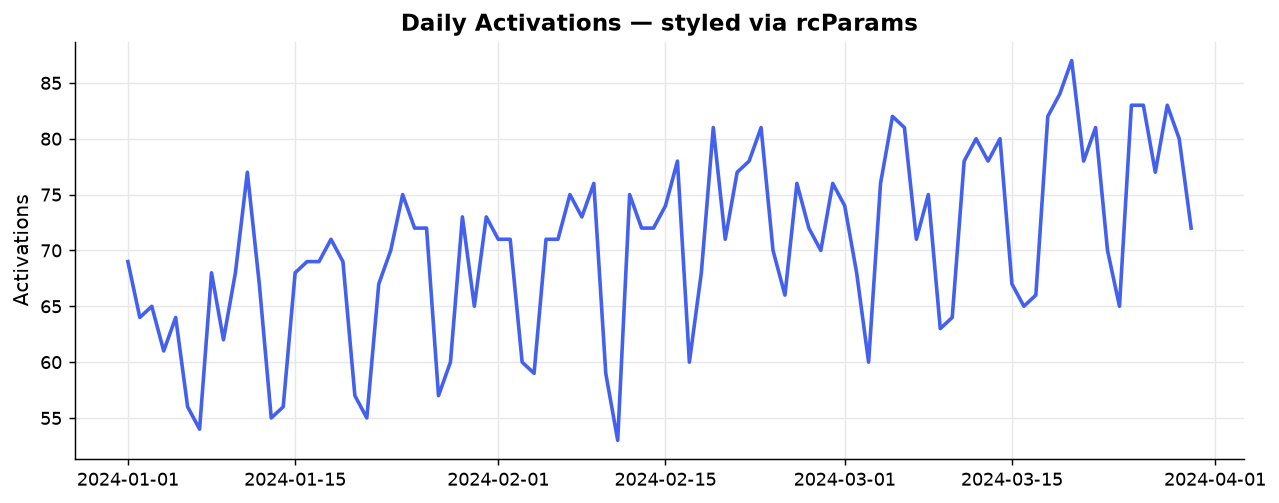

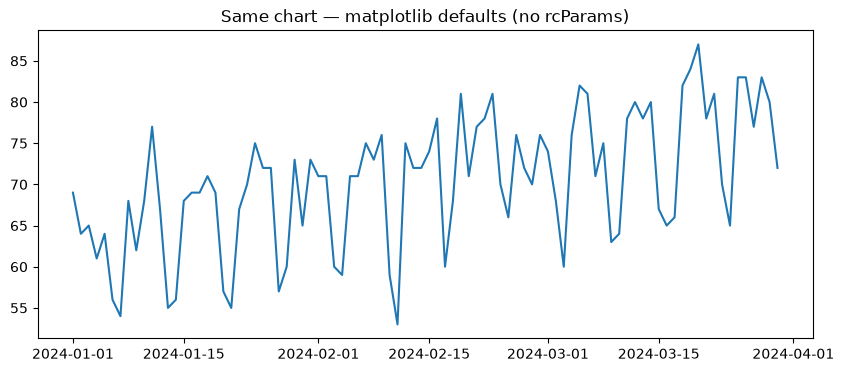

In [4]:
# Chart built with zero manual styling — rcParams does the work
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(daily['date'], daily['activations'], color=COLORS['primary'])
ax.set_title('Daily Activations — styled via rcParams')
ax.set_ylabel('Activations')
plt.show()

# Compare: reset rcParams and see the matplotlib default
plt.rcdefaults()
fig2, ax2 = plt.subplots(figsize=(10, 4))
ax2.plot(daily['date'], daily['activations'])
ax2.set_title('Same chart — matplotlib defaults (no rcParams)')
plt.show()

# Reapply our style
plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': 'white',
    'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'grid.linewidth': 0.8,
    'axes.axisbelow': True, 'lines.linewidth': 2.0, 'legend.frameon': False,
})

## 3 — Typography hierarchy
A chart has four text levels: title → subtitle → axis labels → tick labels.

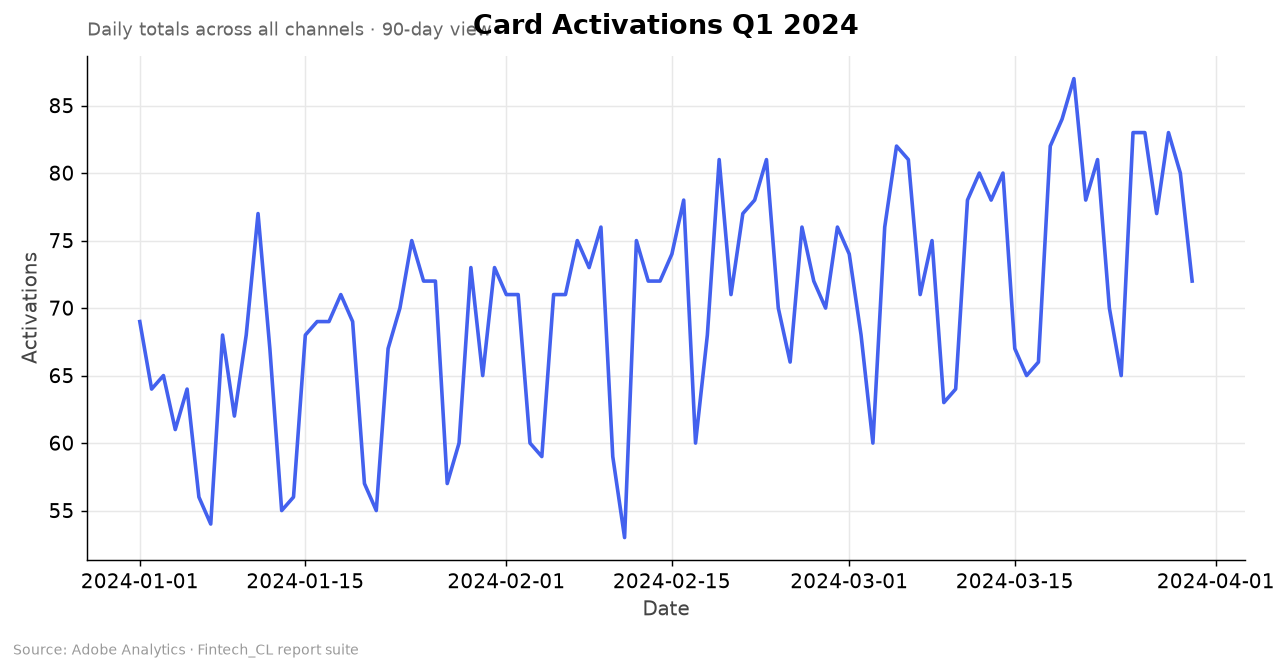

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(daily['date'], daily['activations'], color=COLORS['primary'])

# Level 1: title — largest, bold
ax.set_title('Card Activations Q1 2024', fontsize=15, fontweight='bold', pad=12)

# Level 2: subtitle — smaller, muted color, placed with fig.text or ax.text
ax.text(0.0, 1.04,
        'Daily totals across all channels · 90-day view',
        transform=ax.transAxes,       # 0-1 coordinates relative to the axes
        fontsize=10, color='#666')

# Level 3: axis labels — medium
ax.set_ylabel('Activations', fontsize=11, color='#444')
ax.set_xlabel('Date', fontsize=11, color='#444')

# Level 4: tick labels — smallest (set via rcParams already)

# Source / footnote — even smaller
fig.text(0.01, -0.02, 'Source: Adobe Analytics · Fintech_CL report suite',
         fontsize=8, color='#999')

plt.tight_layout()
plt.show()

## 4 — Bar chart styling in detail

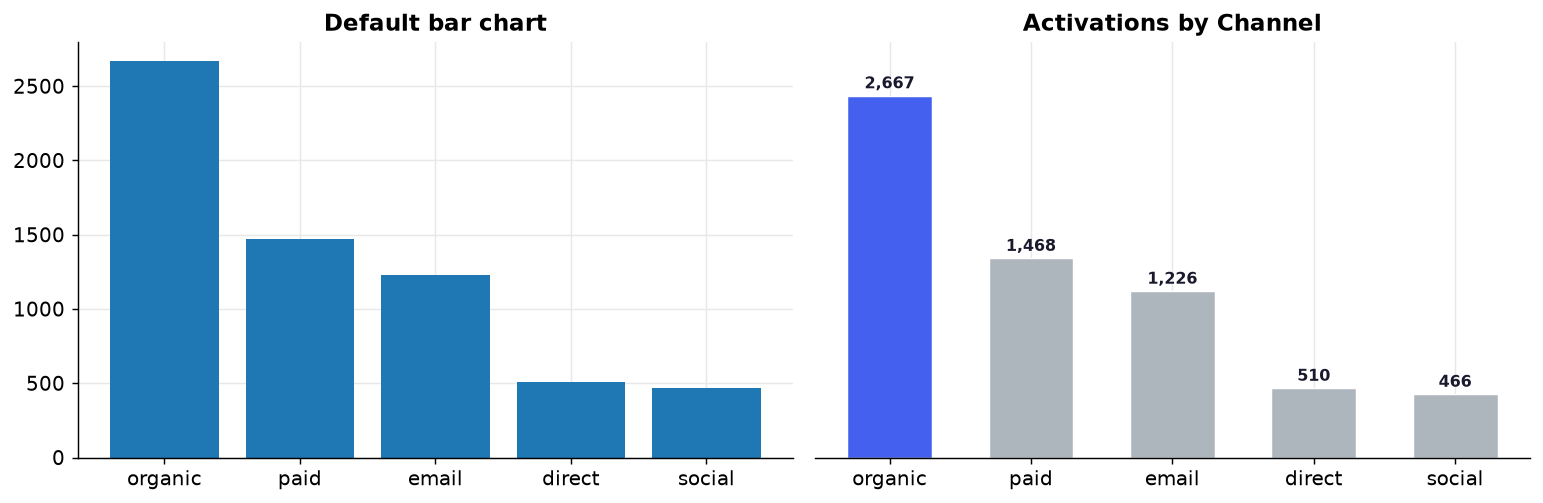

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

channels  = by_channel.index.tolist()
values    = by_channel.values
max_val   = values.max()

# --- Left: default look ---
axes[0].bar(channels, values)
axes[0].set_title('Default bar chart')

# --- Right: polished ---
# Color the top bar differently to highlight the leader
bar_colors = [COLORS['primary'] if v == max_val else COLORS['neutral'] for v in values]
bars = axes[1].bar(channels, values, color=bar_colors,
                   edgecolor='white', linewidth=0.8, width=0.6)

# Value labels on top of each bar
for bar, val in zip(bars, values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max_val * 0.01,
        f'{int(val):,}',
        ha='center', va='bottom', fontsize=9, fontweight='bold',
        color=COLORS['dark']
    )

axes[1].set_title('Activations by Channel')
axes[1].set_ylabel('Total activations')
axes[1].set_ylim(0, max_val * 1.15)   # headroom for labels
axes[1].yaxis.set_visible(False)       # values are already on the bars
axes[1].spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

## 5 — Line chart styling: area fill, markers, emphasis

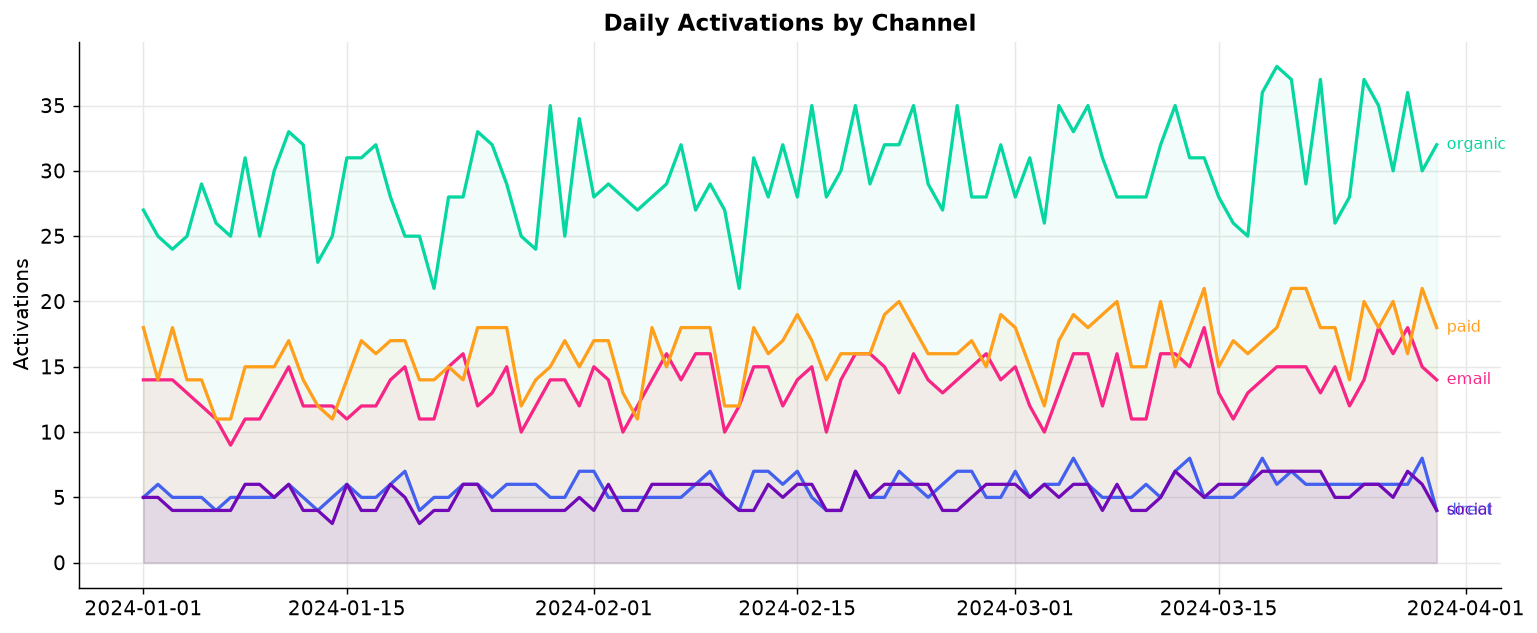

In [7]:
# Multi-channel line chart with consistent color assignment
channel_list = df['channel'].unique()
color_map = dict(zip(sorted(channel_list), CHANNEL_COLORS))

fig, ax = plt.subplots(figsize=(12, 5))

for ch in sorted(channel_list):
    ch_daily = df[df['channel'] == ch].groupby('date')['activacion_tarjeta'].sum().reset_index()
    color = color_map[ch]

    # Main line
    ax.plot(ch_daily['date'], ch_daily['activacion_tarjeta'],
            label=ch, color=color, linewidth=1.8)

    # Subtle fill below
    ax.fill_between(ch_daily['date'], ch_daily['activacion_tarjeta'],
                    alpha=0.05, color=color)

    # Label at the end of each line (cleaner than a legend box)
    last_val  = ch_daily['activacion_tarjeta'].iloc[-1]
    last_date = ch_daily['date'].iloc[-1]
    ax.text(last_date, last_val, f'  {ch}',
            fontsize=9, color=color, va='center')

ax.set_title('Daily Activations by Channel')
ax.set_ylabel('Activations')
plt.tight_layout()
plt.show()

## 6 — Saving for different outputs
Always save as PNG for dashboards/slides. SVG for PDFs and print.

data/06_activations_screen.png: 74 KB
data/06_activations_print.png: 184 KB
data/06_activations.svg: 35 KB


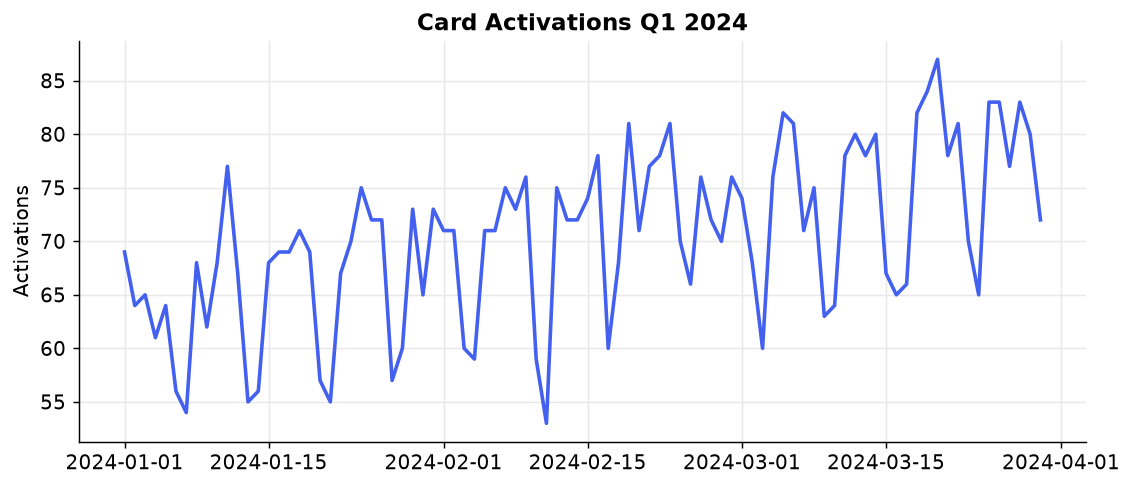

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(daily['date'], daily['activations'], color=COLORS['primary'])
ax.set_title('Card Activations Q1 2024')
ax.set_ylabel('Activations')

# Screen / dashboard: 96-130 dpi, white background
plt.savefig('data/06_activations_screen.png',
            dpi=130, bbox_inches='tight', facecolor='white')

# Print / PDF: 300 dpi minimum
plt.savefig('data/06_activations_print.png',
            dpi=300, bbox_inches='tight', facecolor='white')

# SVG: infinite resolution, editable in Illustrator / Inkscape
plt.savefig('data/06_activations.svg',
            bbox_inches='tight', facecolor='white')

import os
for f in ['data/06_activations_screen.png', 'data/06_activations_print.png', 'data/06_activations.svg']:
    size_kb = os.path.getsize(f) / 1024
    print(f'{f}: {size_kb:.0f} KB')

plt.show()

## 7 — Reusable style function
Extract repeated styling into a function you call on every `ax`.

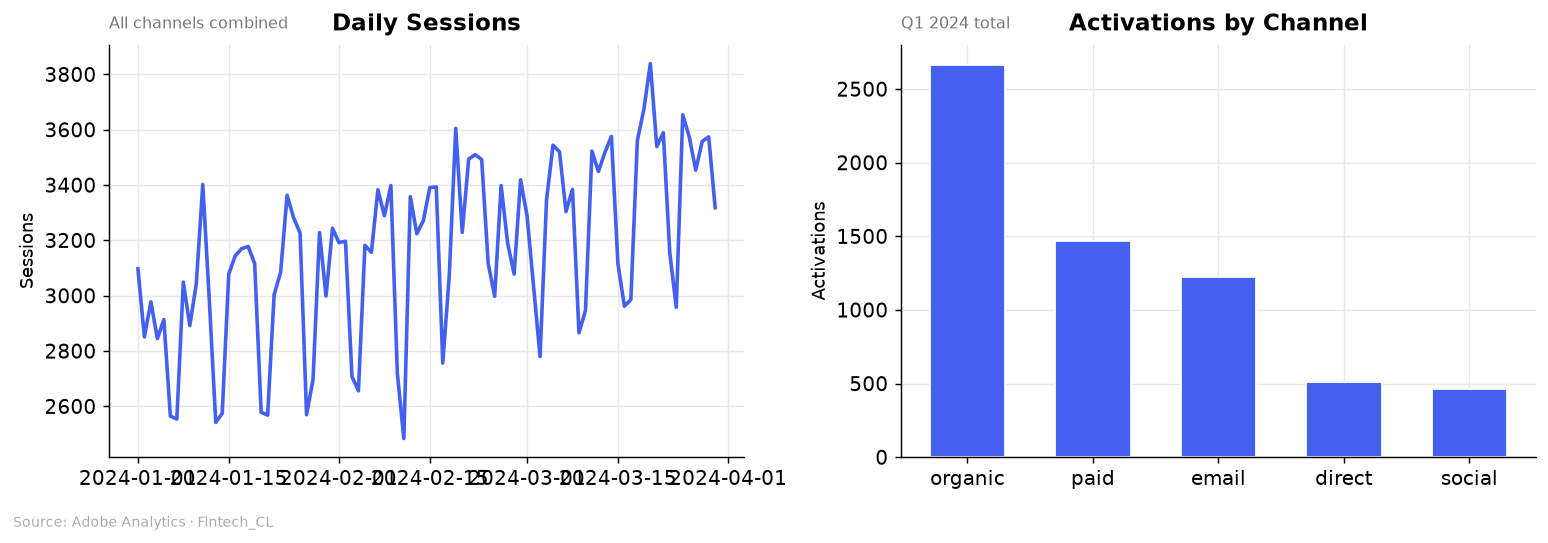

In [9]:
def style_ax(ax, title=None, subtitle=None, xlabel=None, ylabel=None, source=None):
    """Apply standard fintech brand styling to an axes object."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', color='#e8e8e8', linewidth=0.8)
    ax.set_axisbelow(True)

    if title:
        ax.set_title(title, fontsize=13, fontweight='bold', pad=8)
    if subtitle:
        ax.text(0, 1.04, subtitle, transform=ax.transAxes, fontsize=9, color='#777')
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=10)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=10)
    if source:
        ax.figure.text(0.01, -0.03, f'Source: {source}', fontsize=7.5, color='#aaa')


# Use it
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(daily['date'], daily['sessions'], color=COLORS['primary'])
style_ax(axes[0],
         title='Daily Sessions',
         subtitle='All channels combined',
         ylabel='Sessions')

axes[1].bar(channels, values, color=COLORS['primary'], edgecolor='white', width=0.6)
style_ax(axes[1],
         title='Activations by Channel',
         subtitle='Q1 2024 total',
         ylabel='Activations',
         source='Adobe Analytics · Fintech_CL')

plt.tight_layout()
plt.savefig('data/06_styled_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

| Concept | Key idea |
|---|---|
| Color palette | Define `COLORS` dict once, reference everywhere |
| `rcParams.update({})` | Sets global defaults — run once per session |
| Typography hierarchy | Title → subtitle → axis labels → ticks → footnote |
| Bar labels | `ax.text(bar.get_x() + width/2, height, value)` |
| End-of-line labels | Cleaner than a legend for 3+ series |
| `savefig(dpi=130)` | Screen · `dpi=300` → print · `.svg` → editorial |
| `style_ax()` | One function to apply all brand defaults to any axes |

**Next:** `07_export_publication.ipynb` — multi-panel figures, tight layout, PDF exports, figure sizing for slides vs papers.